In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import string
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\galib\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\galib\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\galib\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
df = pd.read_csv("spam.csv", encoding= "latin-1")

In [5]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
925,ham,"K, wait chikku..il send aftr &lt;#&gt; mins",NaN,NaN,NaN
3463,ham,My phone,NaN,NaN,NaN
1525,ham,Pls pls find out from aunt nike.,NaN,NaN,NaN
3603,ham,Hey morning what you come to ask:-) pa...,NaN,NaN,NaN
1146,ham,Babe ? I lost you ... :-(,NaN,NaN,NaN


In [6]:
df.shape

(5572, 5)

## Project planing
##### 1. Data Cleaning
##### 2. EDA
##### 3. Text Preprocessing
##### 4. Model Building
##### 5. Evaluaion
##### 6. Inprovement
##### 7. Website
##### 8. Deploy

# 1. Data Cleaning

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [8]:
# drop last three columns

df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"],inplace=True)

In [9]:
df.sample(5)

,v1,v2
80,ham,"Sorry, I'll call later"
1441,ham,Ya:)going for restaurant..
5012,ham,"Uncle G, just checking up on you. Do have a re..."
3374,ham,:)
4917,ham,Sitting in mu waiting for everyone to get out ...


In [10]:
# renamings columns
df.rename(columns={"v1":"target", "v2":"text"},inplace=True)

df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df["target"]=encoder.fit_transform(df["target"])

In [12]:
df.sample(5)

,target,text
4269,0,Great. Hope you are using your connections fro...
1050,0,Are you available for soiree on June 3rd?
5301,0,At WHAT TIME should i come tomorrow
1865,0,Call to the number which is available in appoi...
3266,0,Ok then i come n pick u at engin?


In [13]:
# Missing values

df.isnull().sum()

target    0
text      0
dtype: int64

In [14]:
# check for duplicate values

df.duplicated().sum()

np.int64(403)

In [15]:
df = df.drop_duplicates(keep="first")

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.shape

(5169, 2)

# 2. EDA

In [18]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
df["target"].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

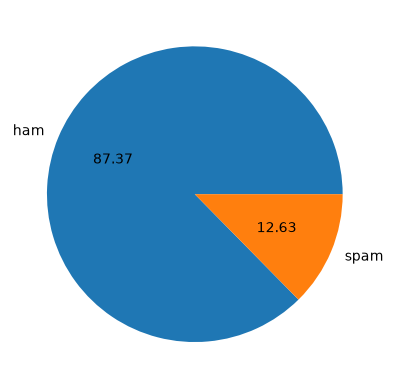

In [20]:
plt.pie(df["target"].value_counts(), labels=["ham","spam"], autopct="%0.2f")
plt.show()

In [21]:
# Data is imbalanced

In [22]:
# Find number of characters in every text columns

df["num_characters"]= df["text"].apply(len) ## এই কোড df["text"] কলামের প্রতিটি row-এর string-এর length (character সংখ্যা) বের করে একটা নতুন Series রিটার্ন করে।


In [23]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [24]:
# find number of words

df["num_words"]= df["text"].apply(lambda x:len(nltk.word_tokenize(x)))

In [25]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [26]:
df["num_sentence"] = df["text"].apply(lambda x:len(nltk.sent_tokenize(x)))

In [27]:
df.head()

,target,text,num_characters,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [28]:
df[["num_characters","num_words","num_sentence"]].describe()

,num_characters,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
# ham

df[df["target"]==0][["num_characters","num_words","num_sentence"]].describe()

,num_characters,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
# spam

df[df["target"]==1][["num_characters","num_words","num_sentence"]].describe()

,num_characters,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


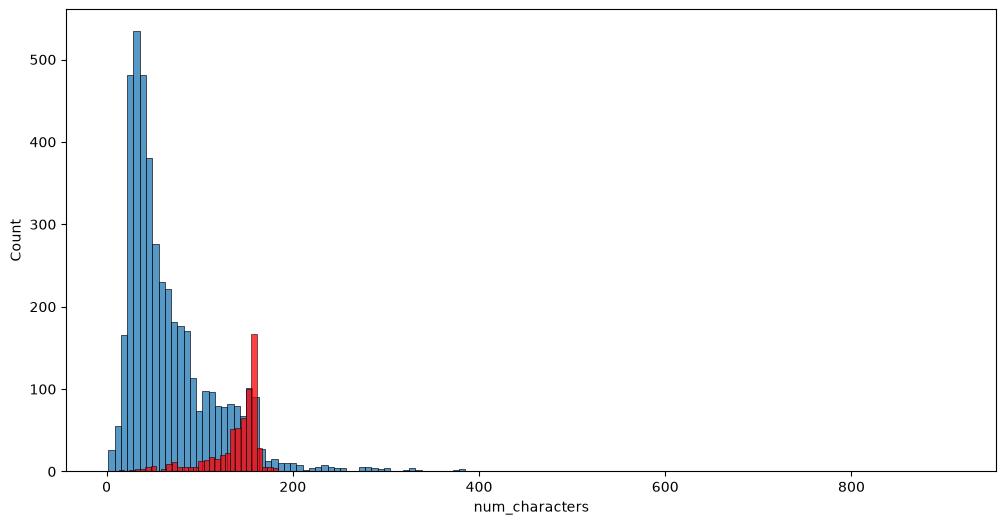

In [31]:
plt.figure(figsize=(12,6))
sns.histplot(df[df["target"]==0]["num_characters"])
sns.histplot(df[df["target"]==1]["num_characters"],color="red")
plt.show()

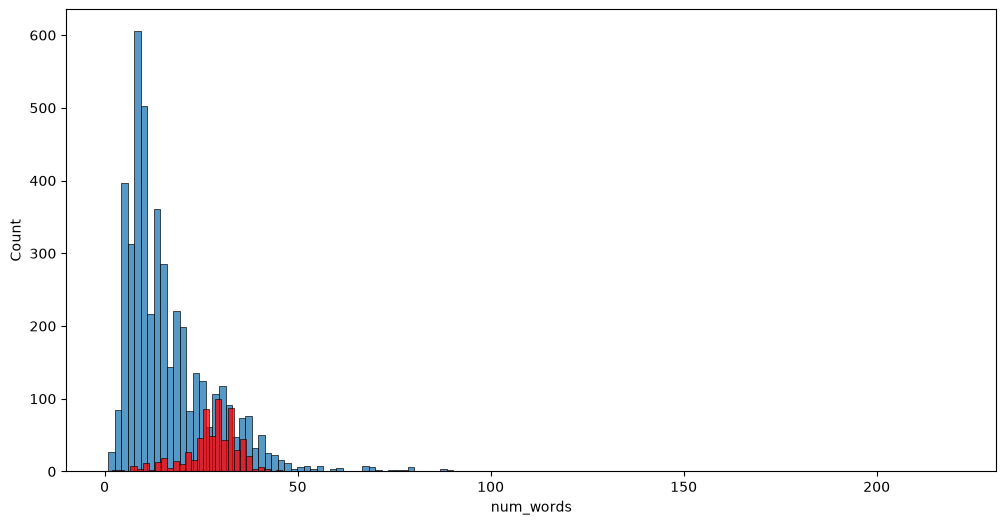

In [32]:
plt.figure(figsize=(12,6))
sns.histplot(df[df["target"]==0]["num_words"])
sns.histplot(df[df["target"]==1]["num_words"],color="red")
plt.show()

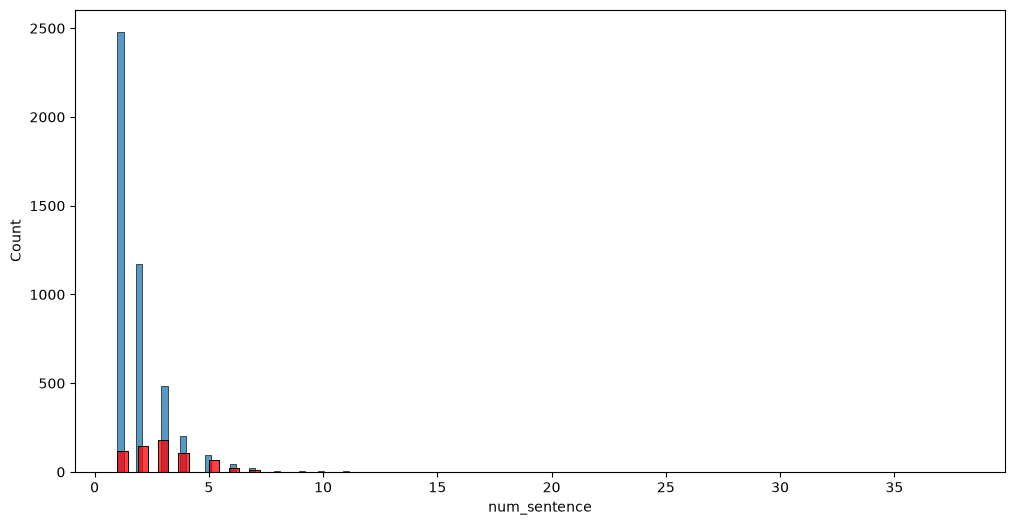

In [33]:
plt.figure(figsize=(12,6))
sns.histplot(df[df["target"]==0]["num_sentence"])
sns.histplot(df[df["target"]==1]["num_sentence"],color="red")
plt.show()

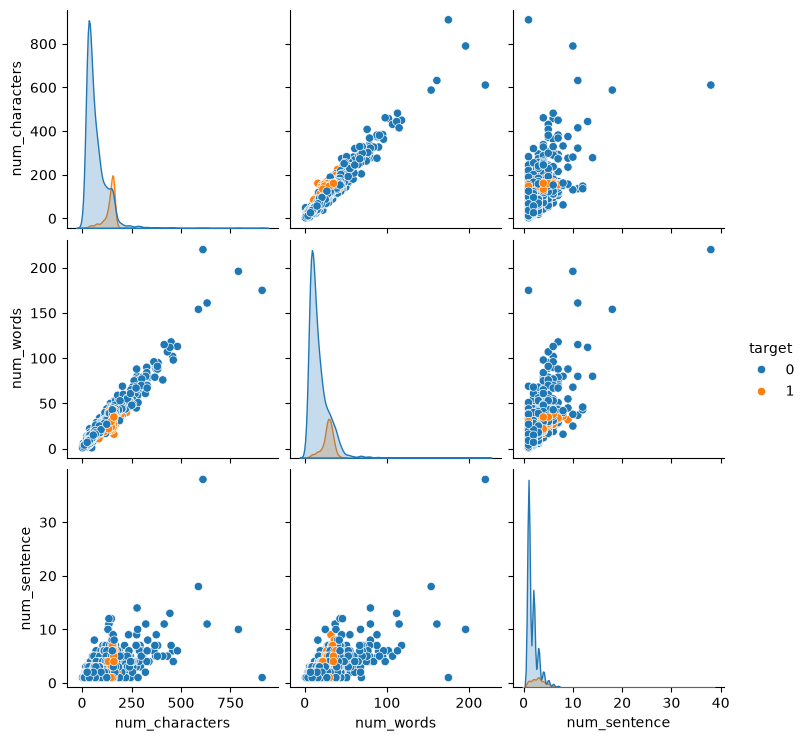

In [34]:
sns.pairplot(df,hue="target")
plt.show()

<Axes: >

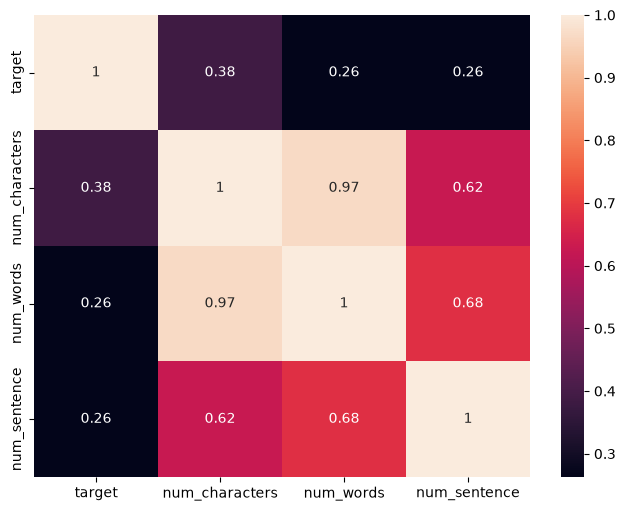

In [35]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only= True),annot= True)

# 3. Data Preprocessing
- Lower case
- Tokenization
- Removing special chatacters
- Removing stop words and punctuation
- Stemming

In [36]:
stopwords = stopwords.words("english")
ps = PorterStemmer()

def text_transformer(text):
    
    # for lower case
    text = text.lower()
    text = nltk.word_tokenize(text)

    # for tokenization
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    # for stop words and punctuation
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords and i not in string.punctuation:
            y.append(i)

    # for stemming
    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [37]:
text_transformer("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [38]:
df["transform_text"] = df["text"].apply(text_transformer)

In [39]:
df.head()

,target,text,num_characters,num_words,num_sentence,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [40]:
from wordcloud import WordCloud

wc = WordCloud(width=500,height=500,min_font_size=10,background_color="white")

In [41]:
spam_wc= wc.generate(df[df["target"]==1]["transform_text"].str.cat(sep=" "))

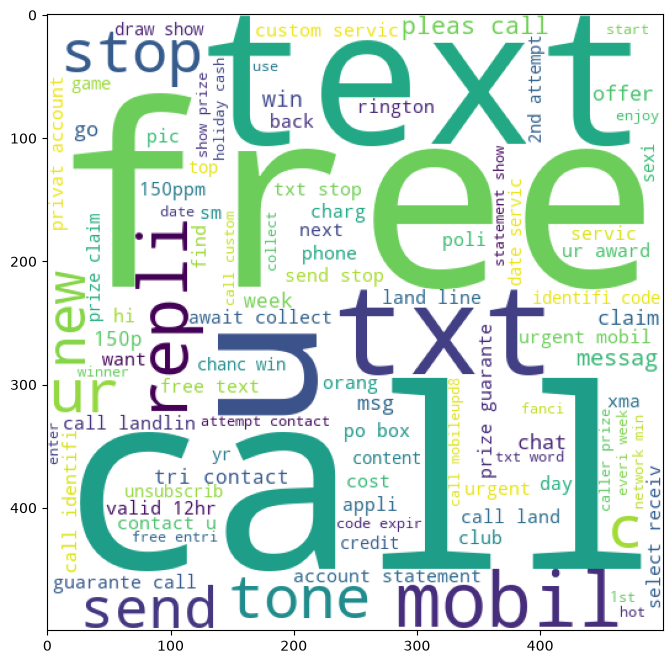

In [42]:
plt.figure(figsize=(12,8))
plt.imshow(spam_wc)
plt.show()

In [43]:
ham_wc= wc.generate(df[df["target"]==0]["transform_text"].str.cat(sep=" "))

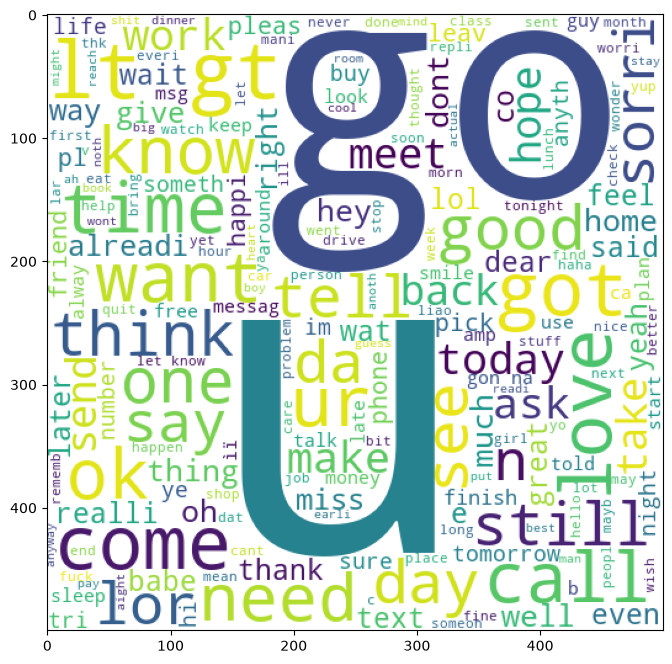

In [44]:
plt.figure(figsize=(12,8))
plt.imshow(ham_wc)
plt.show()

In [45]:
df.head()

,target,text,num_characters,num_words,num_sentence,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [46]:
spam_corpus=[]
for msg in df[df["target"]==1]["transform_text"].tolist():
    for words in msg.split():
        spam_corpus.append(words)

In [47]:
len(spam_corpus)

9939

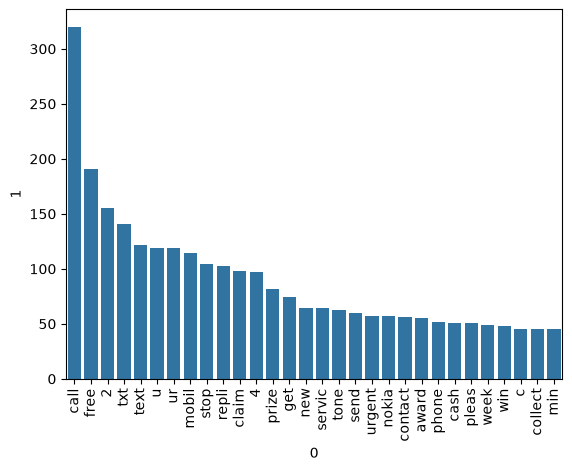

In [48]:
from collections import Counter

df_common_spam = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x= df_common_spam[0],y= df_common_spam[1])
plt.xticks(rotation="vertical")
plt.show()

In [49]:
ham_corpus=[]
for msg in df[df["target"]==0]["transform_text"].tolist():
    for words in msg.split():
        ham_corpus.append(words)

In [50]:
len(ham_corpus)

35404

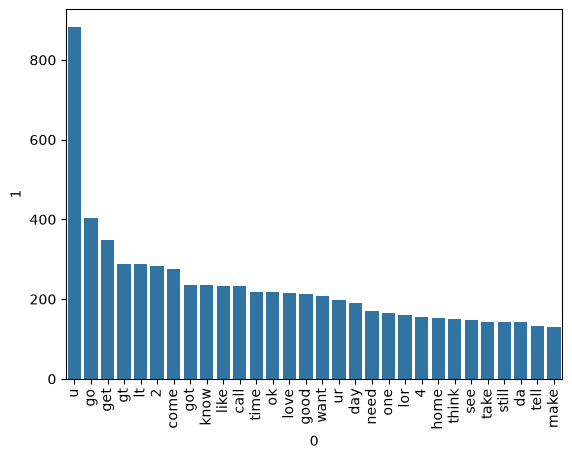

In [51]:
df_common_ham = pd.DataFrame(Counter(ham_corpus).most_common(30))

sns.barplot(x= df_common_ham[0],y= df_common_ham[1])
plt.xticks(rotation="vertical")
plt.show()

In [52]:
## text to Vectorization
## using Bag of Words
df.head()

,target,text,num_characters,num_words,num_sentence,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


# 4. Model Building

In [53]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [54]:
X = tfidf.fit_transform(df["transform_text"]).toarray()

In [55]:
X.shape

(5169, 6708)

In [56]:
y = df["target"].values

In [57]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [60]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

gnb = GaussianNB()
mnb = MultinomialNB()
bnb= BernoulliNB()

In [61]:
gnb.fit(X_train,y_train)
y_pred_1 = gnb.predict(X_test)

print("Accuracy score: ",accuracy_score(y_test,y_pred_1))
print("\nConfusion matrix: \n",confusion_matrix(y_test,y_pred_1))
print("\nPrecision score: ",precision_score(y_test,y_pred_1))

Accuracy score:  0.8762088974854932

Confusion matrix: 
 [[793 103]
 [ 25 113]]

Precision score:  0.5231481481481481


In [62]:
mnb.fit(X_train,y_train)
y_pred_2 = mnb.predict(X_test)

print("Accuracy score: ",accuracy_score(y_test,y_pred_2))
print("\nConfusion matrix: \n",confusion_matrix(y_test,y_pred_2))
print("\nPrecision score: ",precision_score(y_test,y_pred_2))

Accuracy score:  0.9593810444874274

Confusion matrix: 
 [[896   0]
 [ 42  96]]

Precision score:  1.0


In [63]:
bnb.fit(X_train,y_train)
y_pred_3 = bnb.predict(X_test)

print("Accuracy score: ",accuracy_score(y_test,y_pred_3))
print("\nConfusion matrix: \n",confusion_matrix(y_test,y_pred_3))
print("\nPrecision score: ",precision_score(y_test,y_pred_3))

Accuracy score:  0.9700193423597679

Confusion matrix: 
 [[893   3]
 [ 28 110]]

Precision score:  0.9734513274336283


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [65]:
svc = SVC(kernel="sigmoid", gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrg = LogisticRegression(solver="liblinear", penalty="l1")
rfc = RandomForestClassifier(n_estimators= 50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50,random_state=2)
etc = ExtraTreesClassifier(n_estimators=50,random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [66]:
clfs = {
    "SVC": svc,
    "KNN": knc,
    "NB": mnb,
    "DT": dtc,
    "LR": lrg,
    "RF": rfc,
    "AdaBoost": abc,
    "BGC": bc,
    "ETC": etc,
    "GBDT": gbdt,
    "XGB": xgb
}

In [67]:
def train_classifier(clf,X_train,X_test,y_train,y_test):
    clf.fit(X_train,y_train)
    y_pred_ = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred_)
    precision = precision_score(y_test,y_pred_)

    return accuracy, precision

In [68]:
train_classifier(svc,X_train,X_test,y_train,y_test)

(0.9729206963249516, 0.9741379310344828)

In [69]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf,X_train,X_test,y_train,y_test)

    print("For name:",name)
    print("Accuracy: ",current_accuracy)
    print("Precision: ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For name: SVC
Accuracy:  0.9729206963249516
Precision:  0.9741379310344828
For name: KNN
Accuracy:  0.9003868471953579
Precision:  1.0
For name: NB
Accuracy:  0.9593810444874274
Precision:  1.0
For name: DT
Accuracy:  0.9361702127659575
Precision:  0.8461538461538461
For name: LR
Accuracy:  0.9516441005802708
Precision:  0.94


c:\Users\galib\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\galib\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For name: RF
Accuracy:  0.971953578336557
Precision:  1.0
For name: AdaBoost
Accuracy:  0.9245647969052224
Precision:  0.8409090909090909
For name: BGC
Accuracy:  0.9584139264990329
Precision:  0.8625954198473282
For name: ETC
Accuracy:  0.9729206963249516
Precision:  0.9824561403508771
For name: GBDT
Accuracy:  0.9516441005802708
Precision:  0.9230769230769231
For name: XGB
Accuracy:  0.9748549323017408
Precision:  0.9516129032258065


In [77]:
preformence_df = pd.DataFrame({"Algorithm": clfs.keys(), "Accuracy": accuracy_scores, "Precision": precision_scores}).sort_values(by="Precision", ascending=False)

In [78]:
preformence_df

,Algorithm,Accuracy,Precision
1,KNN,0.900387,1.000000
2,NB,0.959381,1.000000
5,RF,0.971954,1.000000
8,ETC,0.972921,0.982456
0,SVC,0.972921,0.974138
10,XGB,0.974855,0.951613
4,LR,0.951644,0.940000
9,GBDT,0.951644,0.923077
7,BGC,0.958414,0.862595
3,DT,0.936170,0.846154


sns.

In [ ]:
perf_long = pd.melt(preformence_df, id_vars="Algorithm", value_vars=["Accuracy","Precision"],
                    var_name="variable", value_name="value")
g = sns.catplot(x="Algorithm", y="value", hue="variable",
                data=perf_long, kind="bar", height=5)
g.set(ylim=(0.5, 1.0))
g.set_xticklabels(rotation=90)
plt.show()
plt.ylim(0.5,1.0)
plt.xticks(rotation= "vertical")
plt.show()

ValueError: Could not interpret value `value` for `y`. An entry with this name does not appear in `data`.